<a href="https://colab.research.google.com/github/Anshu0712-tewatia/Deep-learning/blob/main/DL6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HOUSE PRICE PREDICTION

In [1]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:

# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

In [4]:
# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='sigmoid', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(32, activation='sigmoid'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=512,
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 2.6412 - mae: 1.2268 - val_loss: 1.3893 - val_mae: 0.9646
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3417 - mae: 0.9435 - val_loss: 1.3379 - val_mae: 0.9025
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2813 - mae: 0.8880 - val_loss: 1.3130 - val_mae: 0.9014
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2771 - mae: 0.8975 - val_loss: 1.2767 - val_mae: 0.8818
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2281 - mae: 0.8744 - val_loss: 1.2144 - val_mae: 0.8537
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1584 - mae: 0.8385 - val_loss: 1.1024 - val_mae: 0.8149
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0275 - mae: 0.7903 - val_loss: 0.9365 - val_mae: 0.7284
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8304 - mae: 0.6923 - val_loss: 0.7822 - val_mae: 0.6612
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.70

In [8]:
# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3810 - mae: 0.4240
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Test MAE: 0.42689913511276245
RMSE: 0.6236246796380359
R2 Score: 0.7032165167429524


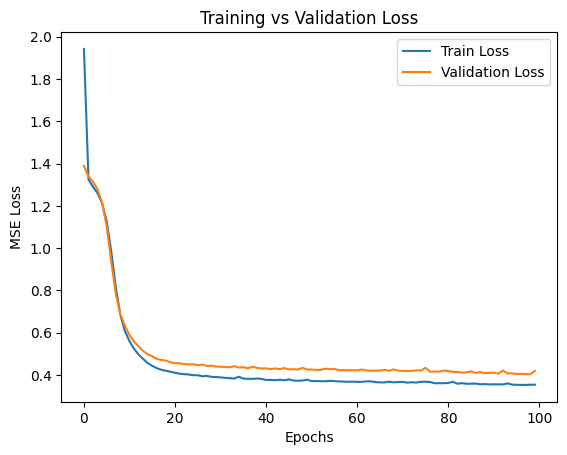

In [9]:
# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

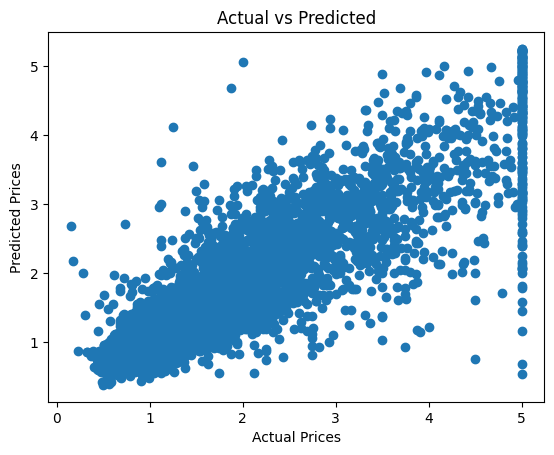

In [10]:
# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()

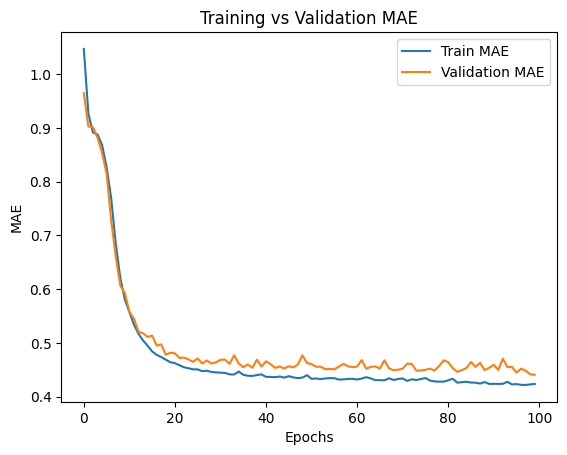

In [11]:
plt.figure()
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.legend()
plt.title("Training vs Validation MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()

In [12]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [15]:
# ==========================================
# 6. Build Multilayer Model (Deeper Network)
# ==========================================

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),

    # New Layer 1
    tf.keras.layers.Dense(64, activation='relu'),

    # New Layer 2
    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(16, activation='relu'),

    # Output Layer
    tf.keras.layers.Dense(1)
])